# YAFS Simulation Trace Analysis

This notebook analyzes the `sim_trace.csv` file generated by the YAFS simulation. It focuses on:
- **Latency Analysis**: End-to-end delay of messages.
- **Service Time**: Processing time within modules.
- **Traffic Distribution**: Message counts per application and module.
- **Topology Flow**: Communication patterns between Fog and Cloud nodes.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set plot style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Load and Inspect Data
Load the CSV file and check the structure.

In [4]:
# Load the dataset
# Update to the specific results file generated by the tutorial
file_path = 'resultados/fog2-middle8-end31-latency-sim_trace.csv'
df = pd.read_csv(file_path)

# Display first rows
display(df.head())

# Check info
print(df.info())

,id,type,app,module,message,DES.src,DES.dst,TOPO.src,TOPO.dst,TOPO.srcLabel,TOPO.dstLabel,module.src,service,time_in,time_out,time_emit,time_reception
0,1,COMP_M,Application-1,Application-1-Service,M_Req,2,1,12,1,Application-1-Sensor,Fog-0,Application-1-Sensor,0.123273,121.811965,121.935238,100.000000,121.811965
1,1,COMP_M,Application-1,Application-1-Sensor,M_Resp,1,2,1,12,Fog-0,Application-1-Sensor,Application-1-Service,0.018243,143.747203,143.765445,121.935238,143.747203
2,2,COMP_M,Application-1,Application-1-Service,M_Req,2,1,12,1,Application-1-Sensor,Fog-0,Application-1-Sensor,0.126282,221.811965,221.938247,200.000000,221.811965
3,2,COMP_M,Application-1,Application-1-Sensor,M_Resp,1,2,1,12,Fog-0,Application-1-Sensor,Application-1-Service,0.012325,243.750212,243.762536,221.938247,243.750212
4,3,COMP_M,Application-2,Application-2-Service,M_Req,7,6,14,1,Application-2-Sensor,Fog-0,Application-2-Sensor,0.076605,321.310235,321.386840,300.000000,321.310235


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38 entries, 0 to 37
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              38 non-null     int64  
 1   type            38 non-null     object 
 2   app             38 non-null     object 
 3   module          38 non-null     object 
 4   message         38 non-null     object 
 5   DES.src         38 non-null     int64  
 6   DES.dst         38 non-null     int64  
 7   TOPO.src        38 non-null     int64  
 8   TOPO.dst        38 non-null     int64  
 9   TOPO.srcLabel   38 non-null     object 
 10  TOPO.dstLabel   38 non-null     object 
 11  module.src      38 non-null     object 
 12  service         38 non-null     float64
 13  time_in         38 non-null     float64
 14  time_out        38 non-null     float64
 15  time_emit       38 non-null     float64
 16  time_reception  38 non-null     float64
dtypes: float64(5), int64(5), object(7)
me

## 2. Data Preprocessing
Calculate key metrics:
- **Latency**: `service`
- **Service Time**: `time_out - time_in`
- **Network/Wait Time**: `Latency - Service Time`

In [5]:
# Calculate Latency (Convert to ms)
df['Latency'] = df['service'] * 1000

# Calculate Service Time (Processing Duration) (Convert to ms)
df['Service_Time'] = (df['time_out'] - df['time_in']) * 1000

# Calculate Network + Wait Time
df['Network_Wait_Time'] = df['Latency'] - df['Service_Time']

# Create a combined label for Application and Node
df['App_Node'] = df['app'] + ' (' + df['TOPO.dstLabel'] + ')'

# Display summary stats for these new metrics
df[['Latency', 'Service_Time', 'Network_Wait_Time']].describe()

,Latency,Service_Time,Network_Wait_Time
count,38.000000,38.000000,3.800000e+01
mean,76.912903,76.912903,-3.179679e-13
std,66.248988,66.248988,4.804947e-11
min,10.945009,10.945009,-1.654072e-10
25%,18.264082,18.264082,-1.735412e-11
50%,50.653723,50.653723,1.039080e-11
75%,140.550430,140.550430,3.223199e-11
max,184.058278,184.058278,6.088641e-11


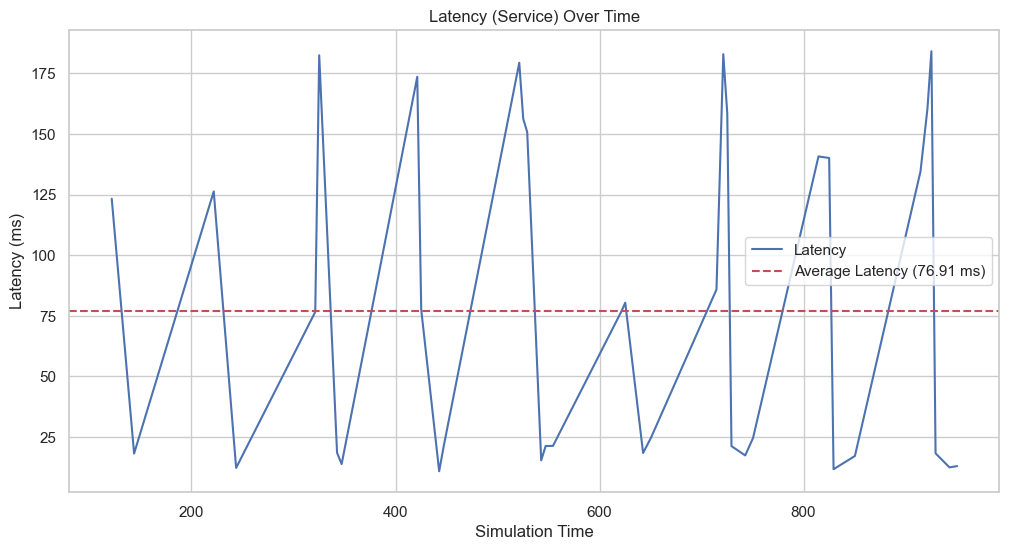

In [6]:
# Simple Line Plot: Latency (Service) over Time
plt.figure(figsize=(12, 6))
sns.lineplot(x='time_reception', y='Latency', data=df, label='Latency')

# Calculate and plot average
mean_latency = df['Latency'].mean()
plt.axhline(y=mean_latency, color='r', linestyle='--', label=f'Average Latency ({mean_latency:.2f} ms)')

plt.title('Latency (Service) Over Time')
plt.xlabel('Simulation Time')
plt.ylabel('Latency (ms)')
plt.legend()
plt.show()

## 3. Descriptive Statistics
Analyze the frequency of applications, modules, and message types.

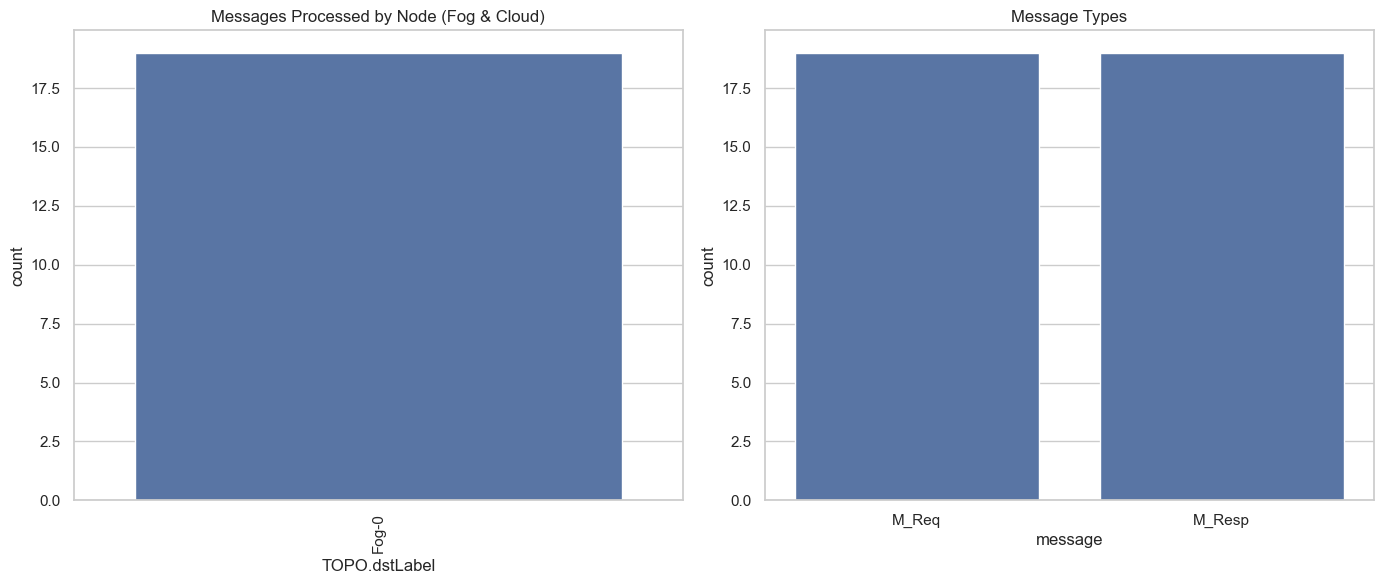

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Messages Processed by Node (Physical Node only)
# Filter for M_Req messages to show only Fog/Cloud nodes (Service providers)
# M_Resp messages go back to Sensors (Users), so we exclude them here.
df_fog_cloud = df[df['message'] == 'M_Req']
sns.countplot(x='TOPO.dstLabel', data=df_fog_cloud, ax=axes[0])
axes[0].set_title('Messages Processed by Node (Fog & Cloud)')
axes[0].tick_params(axis='x', rotation=90)

# 2. Message Types
# We use the 'message' column to distinguish M_Req, M_Resp, M_Act
sns.countplot(x='message', data=df, ax=axes[1])
axes[1].set_title('Message Types')

plt.tight_layout()
plt.show()

## 4. Latency Analysis
Visualize the distribution of latency and compare it across applications.

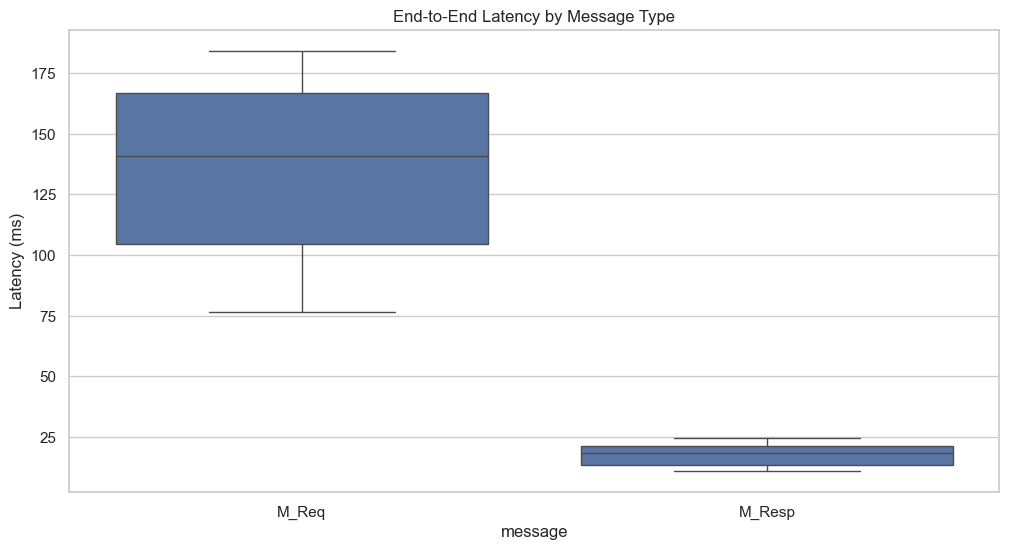

In [8]:
# Latency Distribution by Message Type
plt.figure(figsize=(12, 6))
sns.boxplot(x='message', y='Latency', data=df)
plt.title('End-to-End Latency by Message Type')
plt.ylabel('Latency (ms)')
plt.show()

## 5. Service Time Analysis
Compare processing times across different nodes (Fog vs Cloud).

## 6. Traffic Load Over Time
Check if the traffic is constant or bursty.

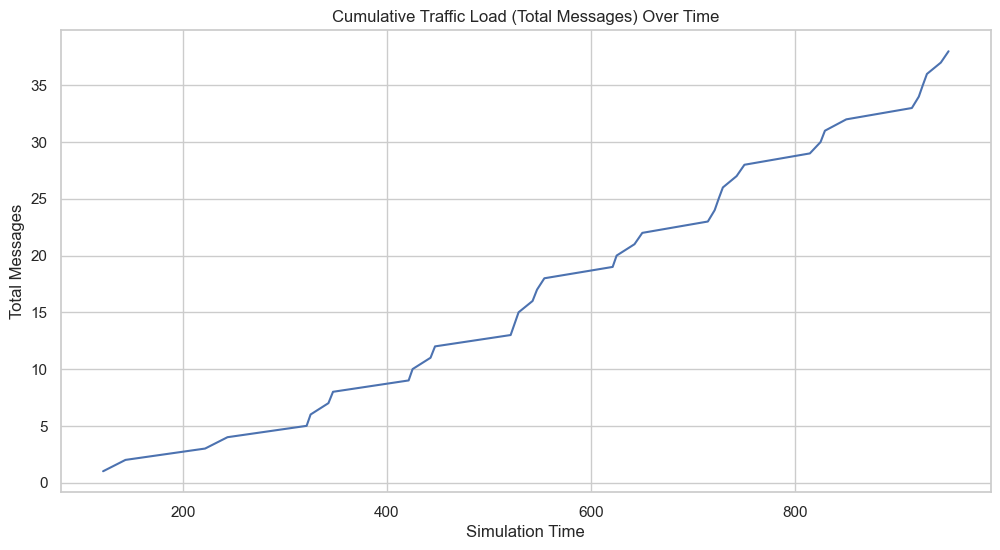

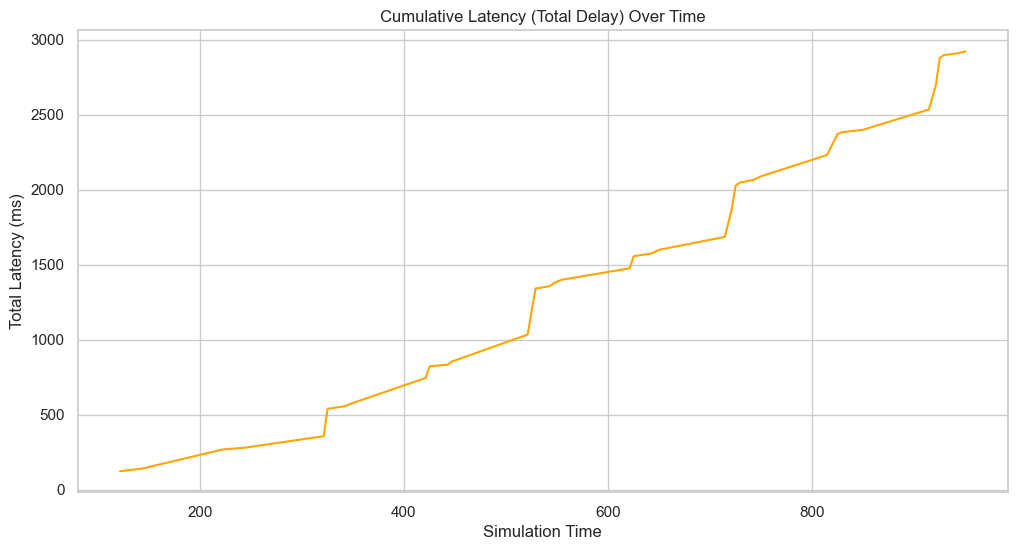

In [9]:
# Sort by time_reception to ensure correct cumulative sum
df_sorted = df.sort_values('time_reception')

# Calculate cumulative sum of messages
df_sorted['cumulative_messages'] = np.arange(1, len(df_sorted) + 1)

# Calculate cumulative sum of latency (in ms)
df_sorted['cumulative_latency'] = (df_sorted['service'] * 1000).cumsum()

# Plot 1: Cumulative Messages
plt.figure(figsize=(12, 6))
sns.lineplot(x='time_reception', y='cumulative_messages', data=df_sorted)
plt.title('Cumulative Traffic Load (Total Messages) Over Time')
plt.xlabel('Simulation Time')
plt.ylabel('Total Messages')
plt.show()

# Plot 2: Cumulative Latency
plt.figure(figsize=(12, 6))
sns.lineplot(x='time_reception', y='cumulative_latency', data=df_sorted, color='orange')
plt.title('Cumulative Latency (Total Delay) Over Time')
plt.xlabel('Simulation Time')
plt.ylabel('Total Latency (ms)')
plt.show()

## 7. Network Topology Flow
Visualize the communication frequency between different nodes.

In [10]:
# Create a pivot table (crosstab) showing communication frequency
communication_table = pd.crosstab(df['TOPO.srcLabel'], df['TOPO.dstLabel'])

print("Communication Table (Source Node vs Destination Node):")
display(communication_table)

Communication Table (Source Node vs Destination Node):


TOPO.dstLabel,Application-1-Sensor,Application-2-Sensor,Application-3-Sensor,Application-4-Sensor,Application-5-Sensor,Fog-0
TOPO.srcLabel,,,,,,
Application-1-Sensor,0,0,0,0,0,5
Application-2-Sensor,0,0,0,0,0,5
Application-3-Sensor,0,0,0,0,0,5
Application-4-Sensor,0,0,0,0,0,3
Application-5-Sensor,0,0,0,0,0,1
Fog-0,5,5,5,3,1,0


## 8. Conclusion
This notebook provides a comprehensive overview of the simulation results.
- **Latency**: Check the boxplots to see if any application suffers from high latency.
- **Service Time**: Compare Fog vs Cloud nodes to see if Fog nodes are processing faster or if they are overloaded.
- **Traffic**: Ensure the load is distributed as expected and not saturating specific nodes (check the Heatmap).

## 6. Unprocessed Messages Analysis (Congestion/Loss)
Analyze messages that did not complete before the simulation ended. This indicates severe congestion or bottlenecks.

In [11]:
import os

unprocessed_path = 'resultados/unprocessed_messages.csv'

if os.path.exists(unprocessed_path):
    df_unprocessed = pd.read_csv(unprocessed_path)
    
    print(f"Total Unprocessed Messages: {len(df_unprocessed)}")
    
    if len(df_unprocessed) > 0:
        display(df_unprocessed.head())
        
        # 1. Count by Queue Type
        plt.figure(figsize=(8, 5))
        sns.countplot(x='QueueType', data=df_unprocessed)
        plt.title('Unprocessed Messages by Queue Type')
        plt.show()
        
        # 2. Count by Application (Top 20)
        top_stuck_apps = df_unprocessed['App'].value_counts().nlargest(20).index
        df_stuck_top20 = df_unprocessed[df_unprocessed['App'].isin(top_stuck_apps)]
        
        plt.figure(figsize=(12, 6))
        sns.countplot(x='App', data=df_stuck_top20, order=top_stuck_apps)
        plt.title('Stuck Messages by Application (Top 20)')
        plt.xticks(rotation=45, ha='right')
        plt.show()
        
        # 3. Distribution of "Until" time (Projected Completion Time)
        # Filter out N/A values if any
        df_unprocessed['Until'] = pd.to_numeric(df_unprocessed['Until'], errors='coerce')
        
        plt.figure(figsize=(10, 6))
        sns.histplot(df_unprocessed['Until'].dropna(), kde=True, color='red')
        plt.title('Projected Completion Time of Stuck Messages')
        plt.xlabel('Simulation Time')
        plt.show()
        
    else:
        print("No unprocessed messages found. Great!")
else:
    print("unprocessed_messages.csv not found.")

Total Unprocessed Messages: 0
No unprocessed messages found. Great!
